# Plots

Load finished runs, inspect final-evaluation artifacts, and generate writeup figures/tables.

## Bootstrap

In [6]:
import json
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('repo_root =', repo_root)


repo_root = /content


## Imports

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['lines.linewidth'] = 2.0


## Config

In [9]:
# Point this at the directory containing your run folders.
runs_root = Path('/content/drive/MyDrive/facialgen_checkpoints')

# Optionally pin a specific subset/order of runs here.
selected_runs = [
    # runs_root / 'coraml_facial_online_resistance_val_T0p50_L1_H1_D8',
    # runs_root / 'coraml_random_na_val_T0p50_L1_H1_D8',
]

# If left empty, the notebook will auto-discover all child directories under runs_root.
if not selected_runs:
    selected_runs = sorted([p for p in runs_root.glob('*') if p.is_dir() and not p.name.startswith('!')])

print('selected_runs =')
for p in selected_runs:
    print(' -', p)


selected_runs =
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_facial_online_resistance_val_V0p10_E0p05T0p50_L1_H1_D8
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_facial_online_resistance_val_V0p10_E0p05_L1_H1_D8
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_random_na_val_V0p10_E0p05T0p50_L1_H1_D8
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_random_na_val_V0p10_E0p05_L1_H1_D8


## Helpers

In [10]:
def load_run_artifacts(run_dir: Path) -> dict:
    out = {'run_dir': run_dir}

    train_args_path = run_dir / 'train_args.json'
    history_path = run_dir / 'history.json'
    meta_path = run_dir / 'final_eval_meta.json'
    lp_path = run_dir / 'final_eval_link_prediction.csv'
    stats_path = run_dir / 'final_eval_graph_stats.csv'
    diag_path = run_dir / 'final_eval_score_diagnostics.csv'

    out['train_args'] = json.loads(train_args_path.read_text()) if train_args_path.exists() else None
    out['history'] = pd.DataFrame(json.loads(history_path.read_text())) if history_path.exists() else pd.DataFrame()
    out['final_meta'] = json.loads(meta_path.read_text()) if meta_path.exists() else None
    out['final_lp'] = pd.read_csv(lp_path) if lp_path.exists() else pd.DataFrame()
    out['final_stats'] = pd.read_csv(stats_path) if stats_path.exists() else pd.DataFrame()
    out['final_diag'] = pd.read_csv(diag_path) if diag_path.exists() else pd.DataFrame()
    return out


def summarize_run_rows(run: dict) -> list[dict]:
    args = run.get('train_args') or {}
    lp = run.get('final_lp', pd.DataFrame()).copy()
    diag = run.get('final_diag', pd.DataFrame()).copy()
    meta = run.get('final_meta') or {}

    history = run.get('history', pd.DataFrame()).copy()
    best_val_roc_auc = float('nan')
    best_val_ap = float('nan')
    if not history.empty and 'val_score' in history.columns:
        scored = history.dropna(subset=['val_score'])
        if not scored.empty:
            best_idx = pd.to_numeric(scored['val_score'], errors='coerce').idxmax()
            best_row = scored.loc[best_idx]
            best_val_roc_auc = best_row.get('val_roc_auc', float('nan'))
            best_val_ap = best_row.get('val_ap', float('nan'))

    base = {
        'run_name': Path(run['run_dir']).name,
        'dataset': args.get('dataset_name'),
        'walk_type': args.get('walk_type'),
        'facial_walk_method': args.get('facial_walk_method'),
        'train_fraction': args.get('train_fraction'),
        'val_fraction': args.get('val_fraction'),
        'test_fraction': args.get('test_fraction'),
        'n_layer': args.get('n_layer'),
        'n_head': args.get('n_head'),
        'n_embd': args.get('n_embd'),
        'num_sign_configs': args.get('num_sign_configs'),
        'val_roc_auc': best_val_roc_auc,
        'val_ap': best_val_ap,
        'checkpoint_dir': meta.get('checkpoint_dir'),
        'gpu_transition_counts': meta.get('gpu_transition_counts'),
        'debug': meta.get('debug'),
    }

    if lp.empty:
        walks_list = meta.get('final_generated_walks_list') or [None]
        return [{**base, 'final_generated_walks': walks} for walks in walks_list]

    if 'final_generated_walks' not in lp.columns:
        lp = lp.copy()
        lp['final_generated_walks'] = (meta.get('final_generated_walks_list') or [None])[0]

    rows = []
    for walks, lp_group in lp.groupby('final_generated_walks', dropna=False, sort=False):
        row = {**base, 'final_generated_walks': walks}
        first = lp_group.iloc[0].to_dict()
        row.update(first)

        if not diag.empty:
            diag_group = diag
            if 'final_generated_walks' in diag.columns:
                diag_group = diag[diag['final_generated_walks'] == walks]
            split_col = 'split' if 'split' in diag_group.columns else 'split_name'
            for _, rec in diag_group.iterrows():
                split = rec.get(split_col)
                if split is None:
                    continue
                row[f'min_8S_over_sumS[{split}]'] = rec.get('min_8S_over_sumS')
                row[f'min_nonzero_gap[{split}]'] = rec.get('min_nonzero_gap')

        rows.append(row)

    return rows


def best_val_epoch(history: pd.DataFrame):
    if history.empty or 'val_score' not in history.columns:
        return None
    scores = pd.to_numeric(history['val_score'], errors='coerce')
    if scores.notna().sum() == 0:
        return None
    idx = scores.idxmax()
    epoch = history.loc[idx].get('epoch')
    return int(epoch) if pd.notna(epoch) else None


## Load Runs


In [11]:
runs = [load_run_artifacts(Path(p)) for p in selected_runs]
summary_rows = []
for run in runs:
    summary_rows.extend(summarize_run_rows(run))
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.sort_values(
        ['dataset', 'train_fraction', 'walk_type', 'facial_walk_method', 'final_generated_walks'],
        na_position='last',
    ).reset_index(drop=True)
print(f'Loaded {len(runs)} runs')
display(summary_df)


Loaded 4 runs


,run_name,dataset,walk_type,facial_walk_method,train_fraction,val_fraction,test_fraction,n_layer,n_head,n_embd,...,val_ap,test_roc_auc,test_ap,edge_overlap[reference],min_8S_over_sumS[train],min_nonzero_gap[train],min_8S_over_sumS[validation],min_nonzero_gap[validation],min_8S_over_sumS[test],min_nonzero_gap[test]
0,coraml_facial_online_resistance_val_V0p10_E0p0...,coraml,facial_online,resistance,0.5,0.1,0.05,1,1,8,...,0.850863,0.854928,0.856691,0.100489,0.000000e+00,2.000000e-06,0.0,2.000000e-06,0.0,2.000000e-06
1,coraml_facial_online_resistance_val_V0p10_E0p0...,coraml,facial_online,resistance,0.5,0.1,0.05,1,1,8,...,0.900204,0.905400,0.907897,0.097356,2.000000e-07,1.000000e-07,0.0,1.000000e-07,0.0,1.000000e-07
2,coraml_random_na_val_V0p10_E0p05T0p50_L1_H1_D8,coraml,random,resistance,0.5,0.1,0.05,1,1,8,...,0.816130,0.810503,0.805956,0.080566,0.000000e+00,2.133333e-06,0.0,2.133333e-06,0.0,2.133333e-06
3,coraml_random_na_val_V0p10_E0p05T0p50_L1_H1_D8,coraml,random,resistance,0.5,0.1,0.05,1,1,8,...,0.853429,0.829994,0.836466,0.075680,0.000000e+00,1.066667e-07,0.0,1.066667e-07,0.0,1.066667e-07
4,coraml_facial_online_resistance_val_V0p10_E0p0...,coraml,facial_online,resistance,NaN,0.1,0.05,1,1,8,...,0.930774,0.928869,0.933132,0.152362,0.000000e+00,2.000000e-06,0.0,2.000000e-06,0.0,2.000000e-06
5,coraml_facial_online_resistance_val_V0p10_E0p0...,coraml,facial_online,resistance,NaN,0.1,0.05,1,1,8,...,0.958072,0.953972,0.960414,0.155494,1.000000e-07,1.000000e-07,0.0,1.000000e-07,0.0,1.000000e-07
6,coraml_random_na_val_V0p10_E0p05_L1_H1_D8,coraml,random,resistance,NaN,0.1,0.05,1,1,8,...,0.940617,0.930644,0.938440,0.176670,0.000000e+00,2.133333e-06,0.0,2.133333e-06,0.0,2.133333e-06
7,coraml_random_na_val_V0p10_E0p05_L1_H1_D8,coraml,random,resistance,NaN,0.1,0.05,1,1,8,...,0.956119,0.946653,0.957423,0.173662,0.000000e+00,1.066667e-07,0.0,1.066667e-07,0.0,1.066667e-07


## Training Curves

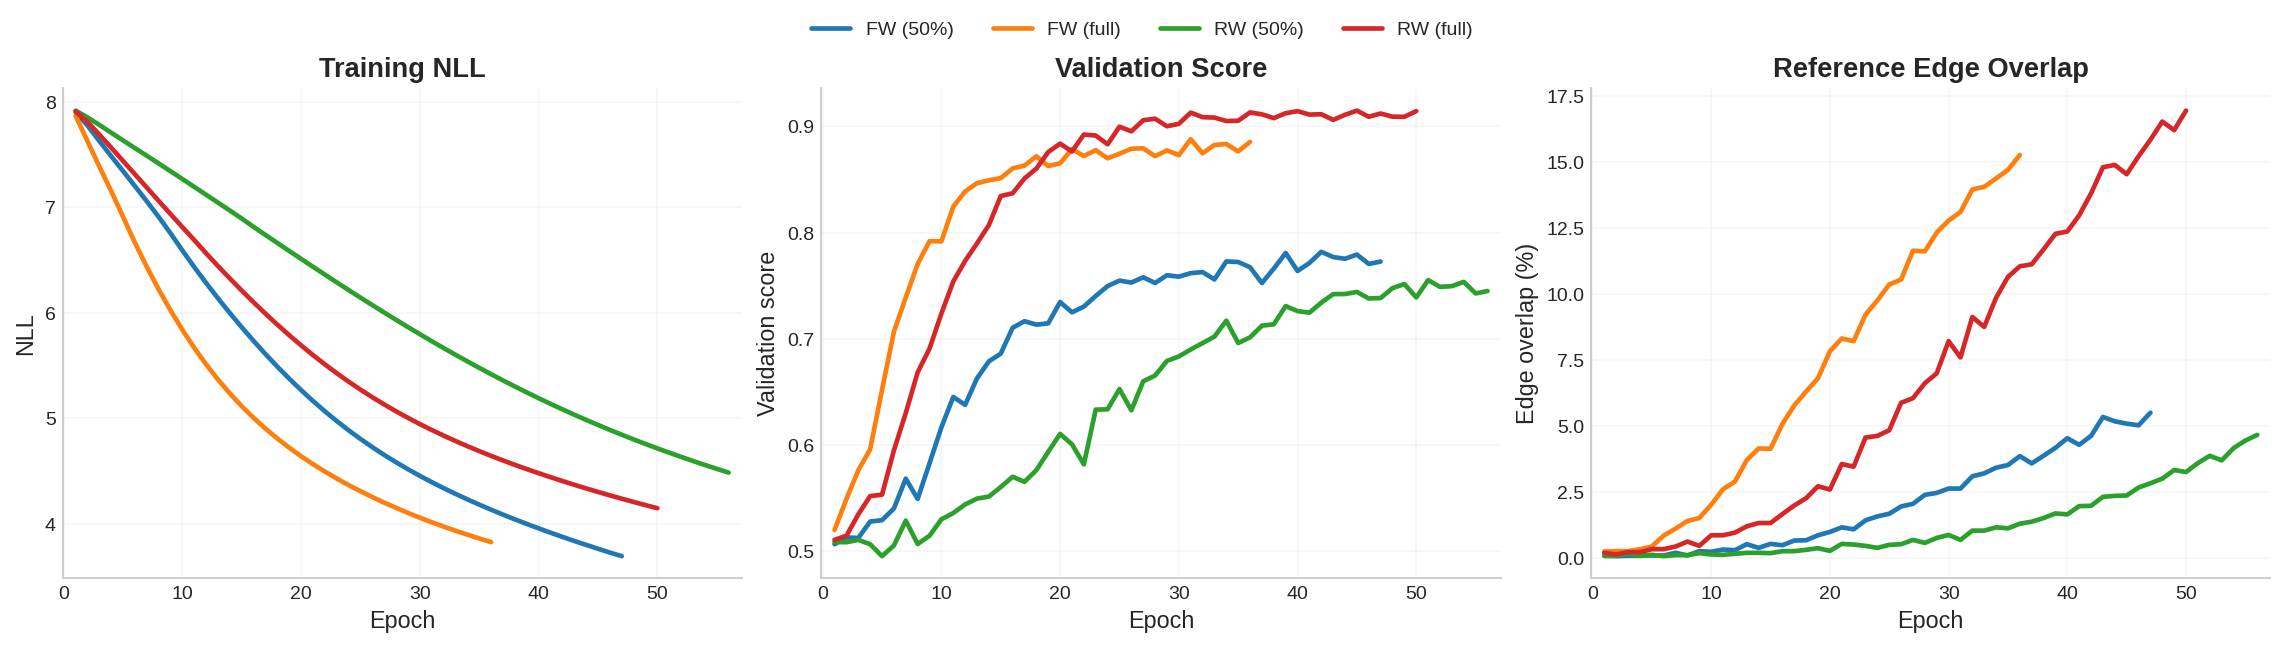

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

# Paper-style plotting defaults.
mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.4,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.8,
})
plt.style.use("seaborn-v0_8-whitegrid")


def fmt_fraction(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return "full"
    value = float(value)
    if value.is_integer():
        return str(int(value))
    return f"{value:g}"



def get_run_value(run, key, default=None):
    if key in run:
        return run.get(key, default)
    args = run.get("train_args") or run.get("args") or {}
    return args.get(key, default)



def run_label(run):
    walk_type = str(get_run_value(run, "walk_type", "unknown"))
    train_fraction = get_run_value(run, "train_fraction")

    if walk_type.startswith("facial"):
        base = "FW"
    elif walk_type == "random_online":
        base = "RW-online"
    elif walk_type == "random":
        base = "RW"
    else:
        base = walk_type.replace("_", " ").title()

    if train_fraction is None or (isinstance(train_fraction, float) and pd.isna(train_fraction)):
        regime = "full"
    else:
        regime = f"{float(train_fraction):.0%}"

    return f"{base} ({regime})"


plot_rows = []
for run in runs:
    history = run.get("history")
    if history is None:
        continue
    if isinstance(history, pd.DataFrame):
        history_rows = history.to_dict("records")
    else:
        history_rows = list(history)
    if len(history_rows) == 0:
        continue
    for row in history_rows:
        if "epoch" not in row:
            continue
        plot_rows.append({
            "label": run_label(run),
            "epoch": row.get("epoch"),
            "val_score": row.get("val_score"),
            "mean_nll": row.get("mean_nll"),
            "edge_overlap": row.get("edge_overlap"),
        })

history_df = pd.DataFrame(plot_rows)
if history_df.empty:
    print("No history data available.")
else:
    history_df = history_df.sort_values(["label", "epoch"]).reset_index(drop=True)
    labels = list(dict.fromkeys(history_df["label"].tolist()))
    palette = plt.get_cmap("tab10")
    color_map = {label: palette(i % 10) for i, label in enumerate(labels)}

    fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.2), constrained_layout=True)
    ax_nll, ax_score, ax_overlap = axes

    for label, group in history_df.groupby("label", sort=False):
        ax_score.plot(
            group["epoch"],
            group["val_score"],
            color=color_map[label],
            label=label,
        )

        mean_nll = group["mean_nll"]
        if mean_nll.notna().any():
            ax_nll.plot(
                group["epoch"],
                mean_nll,
                color=color_map[label],
                label=label,
            )

        edge_overlap = group["edge_overlap"]
        if edge_overlap.notna().any():
            ax_overlap.plot(
                group["epoch"],
                edge_overlap * 100.0,
                color=color_map[label],
                label=label,
            )

    ax_nll.set_title("Training NLL")
    ax_nll.set_xlabel("Epoch")
    ax_nll.set_ylabel("NLL")
    ax_nll.margins(x=0.02)

    ax_score.set_title("Validation Score")
    ax_score.set_xlabel("Epoch")
    ax_score.set_ylabel("Validation score")
    ax_score.margins(x=0.02)

    ax_overlap.set_title("Reference Edge Overlap")
    ax_overlap.set_xlabel("Epoch")
    ax_overlap.set_ylabel("Edge overlap (%)")
    ax_overlap.margins(x=0.02)

    handles, legend_labels = ax_score.get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        frameon=False,
        loc="upper center",
        ncol=min(len(legend_labels), 4),
        bbox_to_anchor=(0.5, 1.08),
    )
    plt.show()


## Final Evaluation Tables

In [15]:
run_idx = 1
run = runs[run_idx]
print('run_dir =', run['run_dir'])
print('final_meta =')
display(pd.DataFrame([run['final_meta']]) if run['final_meta'] else pd.DataFrame())

final_lp = run['final_lp'].copy()
final_stats = run['final_stats'].copy()
final_diag = run['final_diag'].copy()

if 'final_generated_walks' in final_lp.columns:
    final_lp = final_lp.sort_values(['final_generated_walks', 'graph_id'], na_position='last')
if 'final_generated_walks' in final_stats.columns:
    final_stats = final_stats.sort_values(['final_generated_walks', 'metric'], na_position='last')
if 'final_generated_walks' in final_diag.columns:
    split_col = 'split' if 'split' in final_diag.columns else 'split_name'
    final_diag = final_diag.sort_values(['final_generated_walks', 'graph_id', split_col], na_position='last')

print('final link prediction =')
display(final_lp)

print('final graph statistics =')
display(final_stats)

print('final score diagnostics =')
display(final_diag)


run_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_facial_online_resistance_val_V0p10_E0p05_L1_H1_D8
final_meta =


,dataset_name,walk_type,score_symmetrization,edge_overlap_target,final_generated_walks_list,final_max_length,generation_batch_size,gpu_transition_counts,debug,num_generated_graphs,reconstruction_seed,checkpoint_dir
0,coraml,facial_online,sum,reference,"[500000, 10000000]",17,32768,True,False,1,777,/content/drive/MyDrive/facialgen_checkpoints/c...


final link prediction =


,final_generated_walks,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap[reference]
0,500000,0,0.928492,0.930774,0.928869,0.933132,0.152362
1,10000000,0,0.954077,0.958072,0.953972,0.960414,0.155494


final graph statistics =


,final_generated_walks,metric,reference,generated_mean,generated_std
1,500000,assortativity,-0.076592,-0.056094,0.0
5,500000,characteristic_path_len,5.271418,4.350389,0.0
4,500000,clustering_coeff,0.114298,0.028714,0.0
6,500000,inter_community_density,0.000526,0.001340,0.0
7,500000,intra_community_density,0.009280,0.005334,0.0
0,500000,max_degree,246.000000,179.000000,0.0
3,500000,power_law_exp,1.500883,1.484318,0.0
2,500000,triangle_count,5247.000000,977.000000,0.0
9,10000000,assortativity,-0.076592,-0.056902,0.0
13,10000000,characteristic_path_len,5.271418,4.323161,0.0


final score diagnostics =


,final_generated_walks,graph_id,split,num_edges,min_8S_over_sumS,min_nonzero_gap
2,500000,0,test,400,0.000000e+00,2.000000e-06
0,500000,0,train,6783,0.000000e+00,2.000000e-06
1,500000,0,validation,798,0.000000e+00,2.000000e-06
5,10000000,0,test,400,0.000000e+00,1.000000e-07
3,10000000,0,train,6783,1.000000e-07,1.000000e-07
4,10000000,0,validation,798,0.000000e+00,1.000000e-07


## Comparison Plot

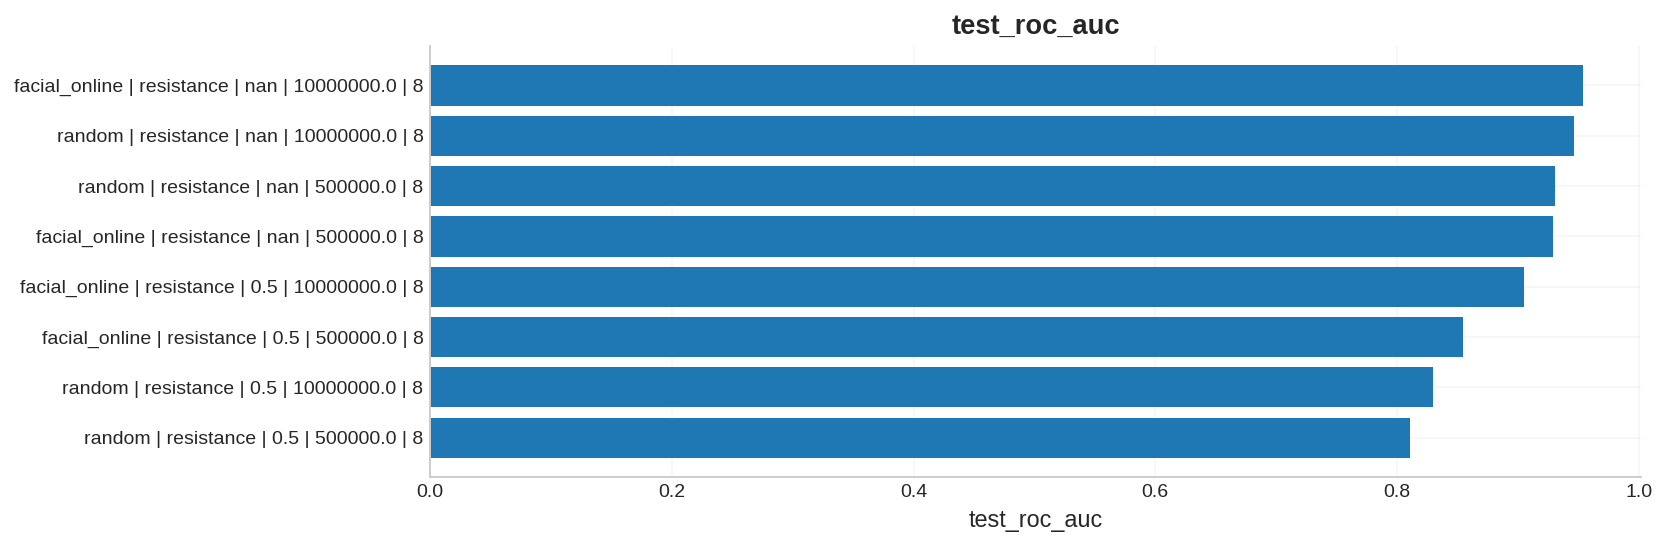

In [16]:
plot_df = summary_df.copy()

metric_col = 'test_roc_auc'
label_cols = ['walk_type', 'facial_walk_method', 'train_fraction', 'final_generated_walks', 'n_embd']
plot_df['label'] = plot_df[label_cols].astype(str).agg(' | '.join, axis=1)
plot_df = plot_df.dropna(subset=[metric_col])
plot_df = plot_df.sort_values(metric_col, ascending=False)

fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df['label'], plot_df[metric_col])
ax.invert_yaxis()
ax.set_title(metric_col)
ax.set_xlabel(metric_col)
plt.tight_layout()
plt.show()


## Paper Table

In [19]:
paper_cols = [
    'run_name',
    'walk_type',
    'facial_walk_method',
    'train_fraction',
    'val_fraction',
    'test_fraction',
    'final_generated_walks',
    'num_sign_configs',
    'n_layer',
    'n_head',
    'n_embd',
    'val_roc_auc',
    'val_ap',
    'test_roc_auc',
    'test_ap',
]

paper_table = summary_df[[c for c in paper_cols if c in summary_df.columns]].copy()
if 'train_fraction' in paper_table.columns and 'final_generated_walks' in paper_table.columns:
    full_train_mask = paper_table['train_fraction'].isna()
    budget_mask = paper_table['final_generated_walks'].isna() | (paper_table['final_generated_walks'] == 10_000_000)
    paper_table = paper_table[(~full_train_mask) | budget_mask].copy()
display(paper_table)


,run_name,walk_type,facial_walk_method,train_fraction,val_fraction,test_fraction,final_generated_walks,num_sign_configs,n_layer,n_head,n_embd,val_roc_auc,val_ap,test_roc_auc,test_ap
0,coraml_facial_online_resistance_val_V0p10_E0p0...,facial_online,resistance,0.5,0.1,0.05,500000.0,256,1,1,8,0.846405,0.850863,0.854928,0.856691
1,coraml_facial_online_resistance_val_V0p10_E0p0...,facial_online,resistance,0.5,0.1,0.05,10000000.0,256,1,1,8,0.893961,0.900204,0.905400,0.907897
2,coraml_random_na_val_V0p10_E0p05T0p50_L1_H1_D8,random,resistance,0.5,0.1,0.05,500000.0,256,1,1,8,0.803692,0.816130,0.810503,0.805956
3,coraml_random_na_val_V0p10_E0p05T0p50_L1_H1_D8,random,resistance,0.5,0.1,0.05,10000000.0,256,1,1,8,0.836107,0.853429,0.829994,0.836466
5,coraml_facial_online_resistance_val_V0p10_E0p0...,facial_online,resistance,NaN,0.1,0.05,10000000.0,256,1,1,8,0.954077,0.958072,0.953972,0.960414
7,coraml_random_na_val_V0p10_E0p05_L1_H1_D8,random,resistance,NaN,0.1,0.05,10000000.0,256,1,1,8,0.953341,0.956119,0.946653,0.957423


## Epoch Inspection

Load a specific checkpoint from a saved run, reconstruct one graph, and inspect its link-prediction metrics, graph statistics, and edge overlap.


In [ ]:
from argparse import Namespace
from pathlib import Path

from facialgen.models import FacialGen
from facialgen.train import build_training_objects
from run_experiment import run_final_evaluation

# Choose the run and checkpoint to inspect.
inspect_run_dir = Path(selected_runs[0]) if selected_runs else None
inspect_epoch = 1          # e.g. 1, 5, 12, 25; use None to load final/
inspect_generated_walks = 500_000
inspect_generation_batch_size = 32_768
inspect_num_generated_graphs = 1
inspect_progress_mode = 'tqdm'
inspect_gpu_transition_counts = True
inspect_debug = False
inspect_reconstruction_seed = 777

if inspect_run_dir is None:
    raise RuntimeError('No selected runs available. Run the Load Runs cell first or set inspect_run_dir manually.')

run = load_run_artifacts(Path(inspect_run_dir))
train_args = run.get('train_args') or {}
if not train_args:
    raise RuntimeError(f'No train_args.json found for {inspect_run_dir}')

reval_args = Namespace(**train_args)
reval_args.final_generated_walks_list = [int(inspect_generated_walks)]
reval_args.final_max_length = None
reval_args.generation_batch_size = int(inspect_generation_batch_size)
reval_args.num_generated_graphs = int(inspect_num_generated_graphs)
reval_args.reconstruction_seed = int(inspect_reconstruction_seed)
reval_args.save_final_eval = False
reval_args.progress_mode = str(inspect_progress_mode)
reval_args.gpu_transition_counts = bool(inspect_gpu_transition_counts)
reval_args.debug = bool(inspect_debug)
reval_args.skip_train = True

# Build eval_info from the run's saved training configuration.
_, _, _, eval_info = build_training_objects(reval_args)

checkpoint_dir = (
    Path(inspect_run_dir) / 'final'
    if inspect_epoch is None
    else Path(inspect_run_dir) / f'epoch_{int(inspect_epoch):03d}'
)
if not checkpoint_dir.exists():
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_dir}')

model = FacialGen.from_pretrained(str(checkpoint_dir))
final_lp, final_stats, final_diag = run_final_evaluation(
    reval_args,
    model=model,
    eval_info=eval_info,
    checkpoint_dir=checkpoint_dir,
)

print(f'Inspected checkpoint: {checkpoint_dir}')
display(final_lp)
display(final_stats)
display(final_diag)
